In [41]:
import pandas as pd
import numpy as np

In [42]:
df = pd.read_csv("Churn_Modelling.csv")

In [43]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [44]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

In [45]:
df.sample(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8111,560,France,Female,31,3,115141.18,1,1,0,39806.75,0
3784,640,France,Female,31,9,138857.59,1,1,0,48640.77,0
4757,743,Spain,Female,36,8,92716.96,1,1,1,33693.78,0
289,588,Spain,Male,34,10,0.00,2,1,0,79078.91,0
4413,615,Germany,Male,39,5,113193.51,2,1,1,52166.25,0
1456,639,Spain,Male,28,8,0.00,2,1,0,126561.07,0
6992,557,France,Female,39,7,49572.73,1,1,0,115287.99,1
1473,552,France,Male,36,8,0.00,2,0,0,132547.02,0
5778,526,France,Female,36,0,0.00,2,1,0,97767.63,0
7792,590,France,Male,40,8,0.00,2,1,0,62933.03,0


In [46]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [47]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [48]:
df = pd.get_dummies(df, columns=['Geography','Gender'],drop_first=True)
# one hot encoding
# drop_first fir removing multicolinearity

In [49]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [50]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [53]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [54]:
model = Sequential()

model.add(Dense(11, activation = 'sigmoid', input_dim = 11))
model.add(Dense(11, activation = 'sigmoid'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
model.compile(optimizer='Adam' ,loss = 'binary_crossentropy', metrics=['accuracy'])

In [57]:
history = model.fit(X_train, y_train, batch_size=50, epochs=100, verbose=1, validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7987 - loss: 0.5682 - val_accuracy: 0.7987 - val_loss: 0.5066
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7864 - loss: 0.5198 - val_accuracy: 0.7987 - val_loss: 0.5015
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7949 - loss: 0.5067 - val_accuracy: 0.7987 - val_loss: 0.4991
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7944 - loss: 0.5059 - val_accuracy: 0.7987 - val_loss: 0.4972
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7892 - loss: 0.5104 - val_accuracy: 0.7987 - val_loss: 0.4960
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7981 - loss: 0.4980 - val_accuracy: 0.7987 - val_loss: 0.4952
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8020 - loss: 0.4942 - val_accuracy: 0.7987 - val_loss: 0.4953
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7901 - loss: 0.5083 - val_acc

In [58]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [59]:
y_pred

array([[0.23785873],
       [0.14373471],
       [0.14373471],
       ...,
       [0.14373471],
       [0.14373471],
       [0.23489343]], dtype=float32)

In [60]:
y_pred = y_pred.argmax(axis=-1)

In [62]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8035

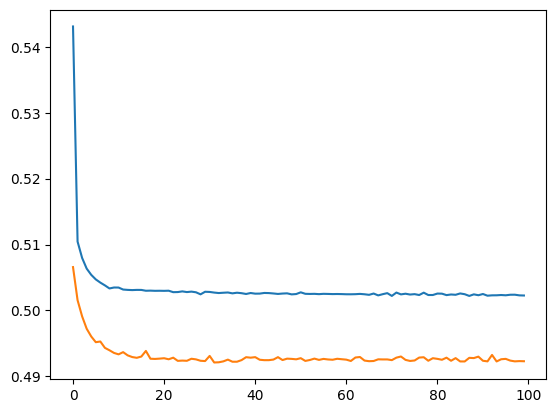

In [63]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

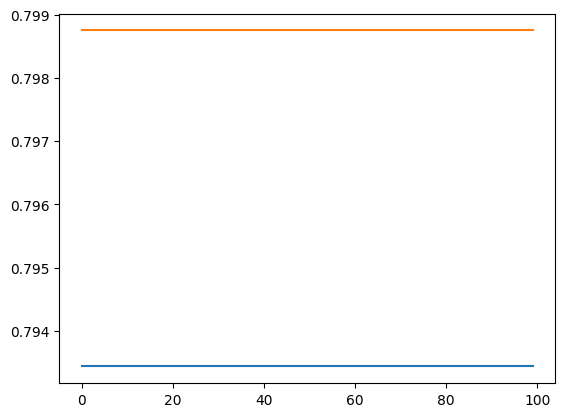

In [64]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])